# Dimensionality Reduction and Topology in Machine Learning


![alt text]({05DBD7DF-2F45-4956-8BE6-2D35EDE44ED6}.png)


### Seeing the invisible structure of data

From raw data → to meaningful shapes  


## ❓ The Problem

Real-world data is NOT 2D.

- A flower  → 4 dimensions
- A sensor  → 10+ dimensions
- AI datasets → 100+ dimensions

But humans can only see in 2D or 3D

So how do we **understand complex data?** 🤔

<img src="highdimdata.png" width="800"/>


## 🌸 Example: Iris Dataset

Each flower is described by:

- Sepal length
- Sepal width
- Petal length
- Petal width

That’s **4D data**

<img src="iris.png" width="800" />

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap
import umap.umap_ as umap
import pandas as pd

In [4]:
# 1. Load the Iris dataset
iris = datasets.load_iris()

# 2. Create a Pandas DataFrame for a beautiful table display
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Raw 4D Data Table (First 5 flowers):")
display(df.head()) 
print(df.shape)


Raw 4D Data Table (First 5 flowers):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


(150, 5)


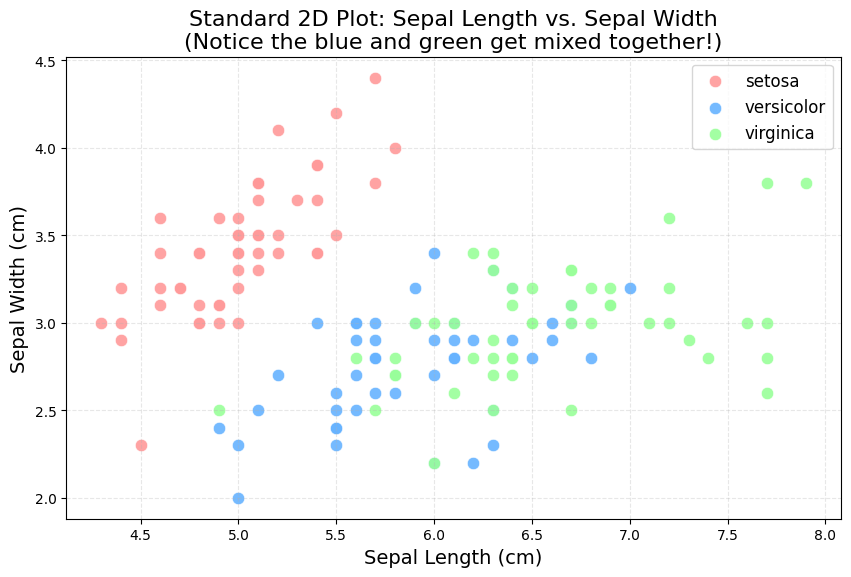

In [5]:

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99']

for i, color, target_name in zip([0, 1, 2], colors, iris.target_names):
    # Filter the dataframe for the specific species
    subset = df[df['Species'] == target_name]
    ax.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'], 
               color=color, alpha=0.9, s=80, label=target_name, edgecolors='white', linewidth=0.5)

ax.set_xlabel('Sepal Length (cm)', fontsize=14)
ax.set_ylabel('Sepal Width (cm)', fontsize=14)
ax.set_title("Standard 2D Plot: Sepal Length vs. Sepal Width\n(Notice the blue and green get mixed together!)", fontsize=16)
ax.legend(fontsize=12)
ax.grid(axis='both', linestyle='--', alpha=0.3)

plt.savefig('0a_iris_table_and_2d_plot.png', dpi=300, bbox_inches='tight')
plt.show()

Why 2D Plots Fail

We try to plot only 2 features:

- Sepal Length vs Sepal Width

But...

❌ Some species overlap  
❌ Important information is lost  

We are only seeing a **partial view**

## Step 2: The "Shadow" Method (Principal Component Analysis)
Humans cannot see in $4D$. To look for patterns, we must squash the data down to $2D$. 

The traditional way to do this in Linear Algebra is **PCA (Principal Component Analysis)**. 
Think of PCA as shining a bright flashlight onto a complex shape to cast a flat, $2D$ shadow on the wall. It finds the widest angle to cast the shadow, but because it's rigid, some data gets crushed on top of each other. Let's see what happens to our Iris flowers.

NameError: name 'y' is not defined

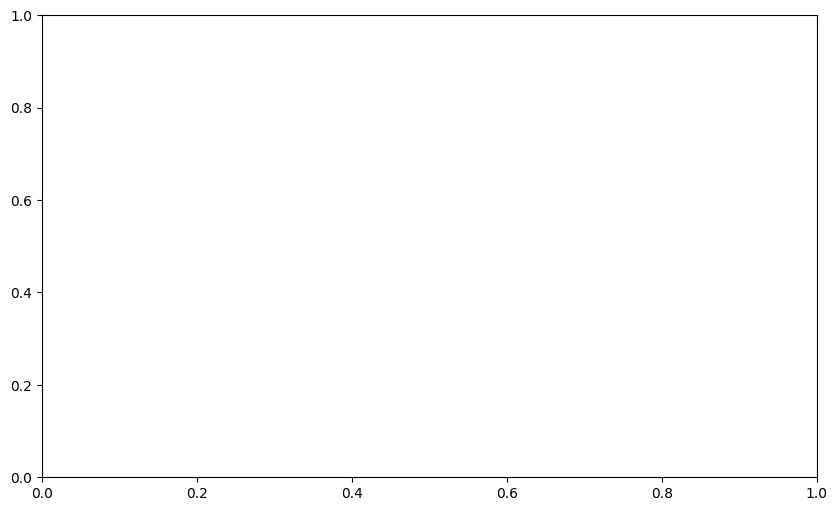

In [ ]:

# 1. Apply PCA to reduce 4D to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X) 

# 2. Calculate how much information we "kept" vs "lost" in the shadow
variance_retained = sum(pca.explained_variance_ratio_) * 100
variance_lost = 100 - variance_retained

# 3. Create the Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99']

# Plot the squashed 2D data
for i, color, target_name in zip([0, 1, 2], colors, iris.target_names):
    ax.scatter(X_pca[y == i, 0], X_pca[y == i, 1], 
               color=color, alpha=0.9, s=80, label=target_name, edgecolors='white', linewidth=0.5)

ax.set_xlabel('Principal Component 1 (Widest Angle)', fontsize=14)
ax.set_ylabel('Principal Component 2', fontsize=14)
ax.set_title(f"PCA Projection: 4D Squashed to 2D\nInformation Retained: {variance_retained:.1f}% | Information Squashed/Lost: {variance_lost:.1f}%", fontsize=16)
ax.legend(fontsize=12)
ax.grid(axis='both', linestyle='--', alpha=0.3)

plt.show()

print(f"Mathematical Proof: We lost {variance_lost:.1f}% of the true structure by crushing it flat.")

## Step 3: The "Neighborhood" Method (t-SNE)
Since PCA was too rigid and mashed our green and blue flowers together, we need a different approach. 

Enter **t-SNE**. Instead of shining a light from far away to cast a shadow, t-SNE works like a mapmaker walking through a city. It only looks at its immediate neighbors. It tries to pull points that are close together in $4D$ space close together on the $2D$ screen, while pushing different points far away. Let's see if this local "neighborhood" approach can untangle our flowers.


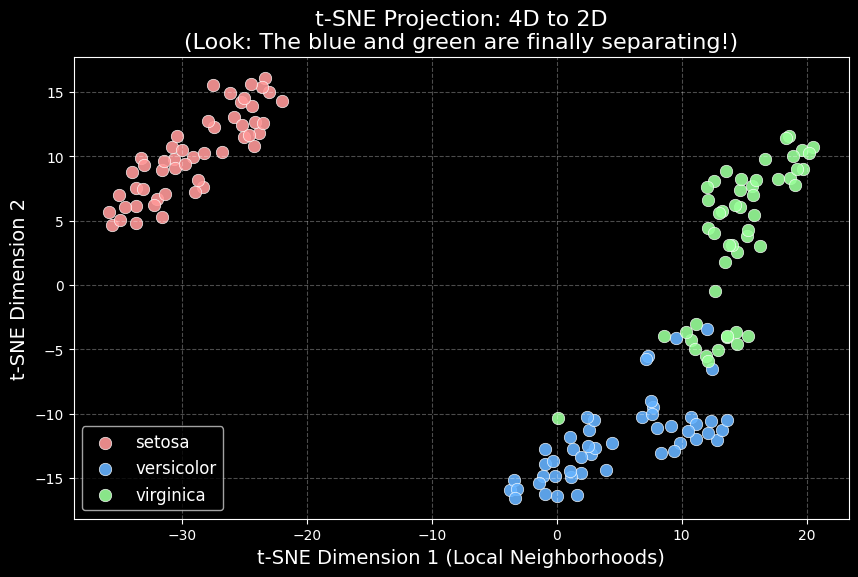

In [16]:
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
X_tsne = tsne.fit_transform(X) # X is still our iris.data

# 2. Create the Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99']

# Plot the neighborhood-mapped 2D data
for i, color, target_name in zip([0, 1, 2], colors, iris.target_names):
    ax.scatter(X_tsne[y == i, 0], X_tsne[y == i, 1], 
               color=color, alpha=0.9, s=80, label=target_name, edgecolors='white', linewidth=0.5)

ax.set_xlabel('t-SNE Dimension 1 (Local Neighborhoods)', fontsize=14)
ax.set_ylabel('t-SNE Dimension 2', fontsize=14)
ax.set_title("t-SNE Projection: 4D to 2D\n(Look: The blue and green are finally separating!)", fontsize=16)
ax.legend(fontsize=12)
ax.grid(axis='both', linestyle='--', alpha=0.3)

plt.show()

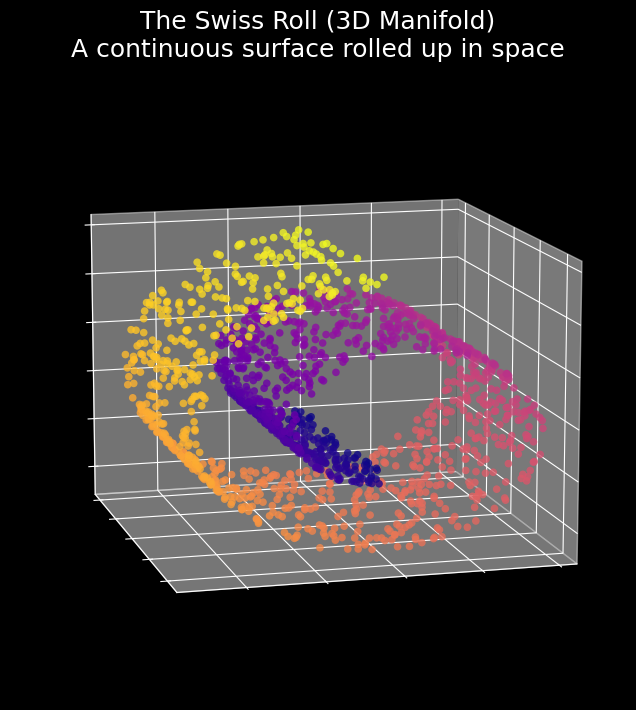

In [17]:
from sklearn.datasets import make_swiss_roll

# 1. Generate the Swiss Roll dataset
# We use 1500 points. 'color_sequence' maps to the actual position on the unrolled carpet.
X_swiss, color_sequence = make_swiss_roll(n_samples=1500, noise=0.05, random_state=42)

# 2. Create the 3D Visualization
fig = plt.figure(figsize=(10, 8))
# Add a 3D axis
ax = fig.add_subplot(111, projection='3d')

# Plot the points. We use the 'plasma' colormap because it looks amazing on dark backgrounds.
scatter = ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], 
                     c=color_sequence, cmap='plasma', s=30, alpha=0.8, edgecolors='none')

ax.set_title("The Swiss Roll (3D Manifold)\nA continuous surface rolled up in space", fontsize=18, pad=20)

# Remove the confusing axis numbers so the audience just focuses on the shape
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

# Rotate the camera for the absolute best viewing angle of the spiral
ax.view_init(elev=12, azim=75)

# Save the high-resolution image for your slide
plt.savefig('3_swiss_roll_3d.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Step 4.5: The "Just Look at It from the Side" Failed Experiment

Before using AI, people often ask: *"Why don't we just look at two axes at a time, like a normal 2D graph?"*

Let's try that. Let's take our 3D Swiss Roll and just plot the X-axis against the Y-axis, and then the X-axis against the Z-axis. This is the equivalent of looking at the rolled-up carpet purely from the top, and then purely from the side. Notice how the colors—which represent the true distance along the carpet—are completely scrambled.

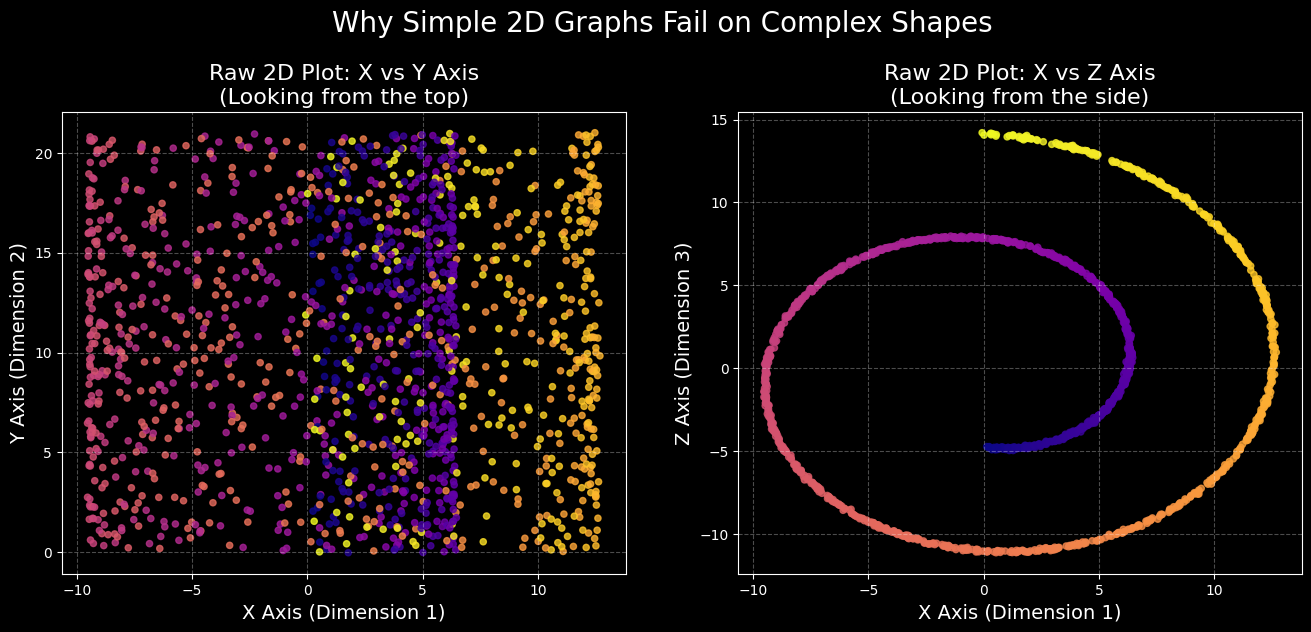

In [18]:
import matplotlib.pyplot as plt

# We use the X_swiss and color_sequence generated in the previous cell

# Create a side-by-side plot layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Projection 1: X vs Y (Looking from the top down)
ax1.scatter(X_swiss[:, 0], X_swiss[:, 1], c=color_sequence, cmap='plasma', s=20, alpha=0.8)
ax1.set_title("Raw 2D Plot: X vs Y Axis\n(Looking from the top)", fontsize=16)
ax1.set_xlabel("X Axis (Dimension 1)", fontsize=14)
ax1.set_ylabel("Y Axis (Dimension 2)", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.3)

# Projection 2: X vs Z (Looking from the side)
ax2.scatter(X_swiss[:, 0], X_swiss[:, 2], c=color_sequence, cmap='plasma', s=20, alpha=0.8)
ax2.set_title("Raw 2D Plot: X vs Z Axis\n(Looking from the side)", fontsize=16)
ax2.set_xlabel("X Axis (Dimension 1)", fontsize=14)
ax2.set_ylabel("Z Axis (Dimension 3)", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.3)

plt.suptitle("Why Simple 2D Graphs Fail on Complex Shapes", fontsize=20, y=1.05)

# Save the high-resolution image for your slide
plt.savefig('3a_swiss_roll_raw_2d.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 5: Machine Learning Tries (and Struggles)

We know human 2D graphs fail. Let's give the problem to our Machine Learning algorithms to see if they can flatten the 3D Swiss Roll into 2D while keeping the color gradient intact.

1. **PCA (Linear Algebra):** It tries to cast a flat shadow. Because the roll curves over itself, the shadow crushes different layers of the roll on top of each other.
2. **t-SNE (Local Neighborhoods):** It tries to keep close neighbors together. It successfully groups similar colors, but because it doesn't understand the *global* shape of the carpet, it tears the roll into dozens of disconnected, shattered islands!

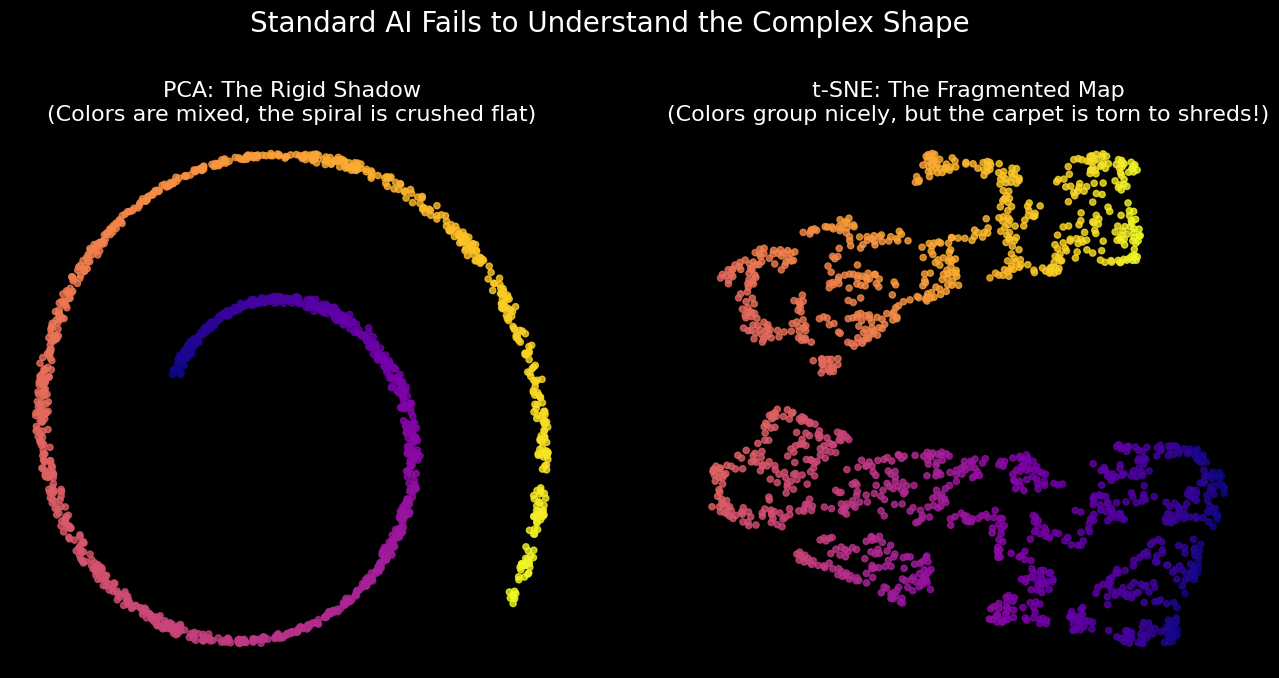

In [19]:
pca_swiss = PCA(n_components=2)
X_pca_swiss = pca_swiss.fit_transform(X_swiss)

# 2. Apply t-SNE (The Neighborhood Method)
# Note: t-SNE is computationally heavy. It might take 10-20 seconds to run on your machine!
tsne_swiss = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_swiss = tsne_swiss.fit_transform(X_swiss)

# 3. Create the Side-by-Side Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot PCA
ax1.scatter(X_pca_swiss[:, 0], X_pca_swiss[:, 1], c=color_sequence, cmap='plasma', s=20, alpha=0.8)
ax1.set_title("PCA: The Rigid Shadow\n(Colors are mixed, the spiral is crushed flat)", fontsize=16)
ax1.axis('off') # Turn off axes to make it look clean like modern art

# Plot t-SNE
ax2.scatter(X_tsne_swiss[:, 0], X_tsne_swiss[:, 1], c=color_sequence, cmap='plasma', s=20, alpha=0.8)
ax2.set_title("t-SNE: The Fragmented Map\n(Colors group nicely, but the carpet is torn to shreds!)", fontsize=16)
ax2.axis('off')

plt.suptitle("Standard AI Fails to Understand the Complex Shape", fontsize=20, y=1.05)

# Save the high-resolution image for your slide
plt.savefig('4_swiss_roll_pca_vs_tsne.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Step 6: The Hero Arrives (Topology & UMAP)

How do we flatten a rolled-up carpet without crushing it or tearing it? We use the math of flexible shapes: **Topology**.

Remember from the beginning of the stand: topology allows us to stretch and bend shapes as long as we don't break them. A modern algorithm called **UMAP (Uniform Manifold Approximation and Projection)** uses topological data analysis to look at the Swiss Roll. 

Instead of drawing straight lines through empty space, UMAP mathematically traces the continuous surface of the data. It finds the edge of the carpet, stretches it out, and smoothly unrolls it onto our 2D screen. Let's watch it work.

c:\Users\hp\OneDrive\Documents\Math Maroc\MDM\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


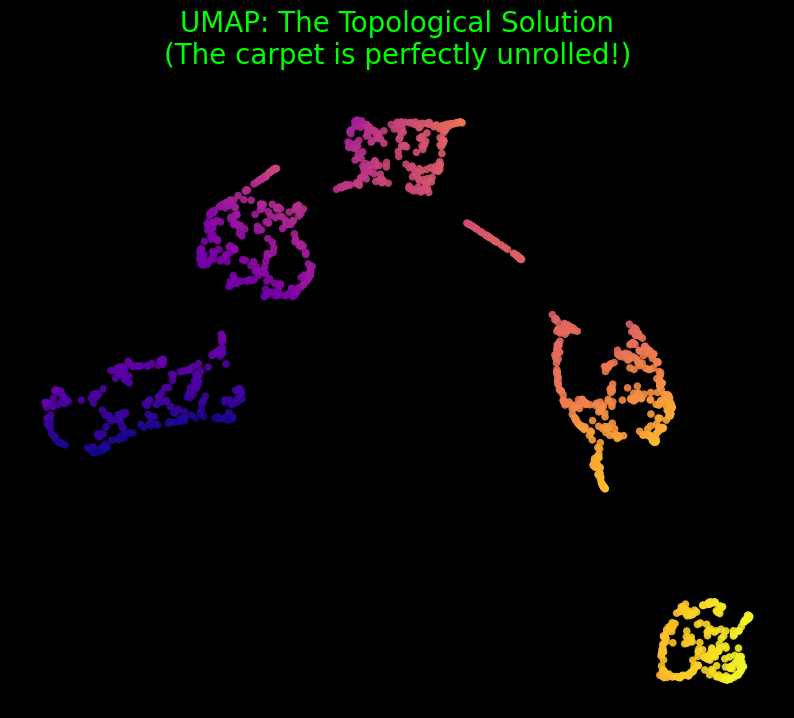

In [26]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

# 1. Apply UMAP (The Topological Method)
# n_neighbors tells UMAP how much to focus on local vs global structure
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap_swiss = reducer.fit_transform(X_swiss)

# 2. Create the Final Visualization
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the unrolled data
scatter = ax.scatter(X_umap_swiss[:, 0], X_umap_swiss[:, 1], 
                     c=color_sequence, cmap='plasma', s=30, alpha=0.9, edgecolors='none')

ax.set_title("UMAP: The Topological Solution\n(The carpet is perfectly unrolled!)", fontsize=20, color='lime', pad=20)
ax.axis('off') # Keep it clean

# Save the high-resolution image for your final slide
plt.savefig('5_swiss_roll_umap.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

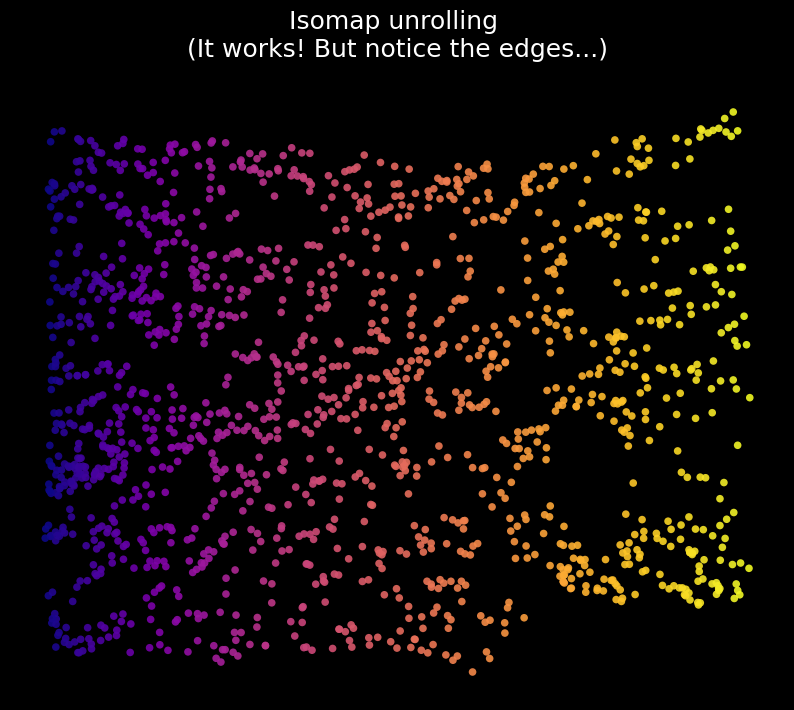

In [22]:
isomap = Isomap(n_components=2, n_neighbors=10)
X_isomap_swiss = isomap.fit_transform(X_swiss)

# 2. Create the Visualization
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the unrolled data
scatter = ax.scatter(X_isomap_swiss[:, 0], X_isomap_swiss[:, 1], 
                     c=color_sequence, cmap='plasma', s=30, alpha=0.9, edgecolors='none')

ax.set_title("Isomap unrolling \n(It works! But notice the edges...)", fontsize=18, pad=20)
ax.axis('off') 

# Save the high-resolution image
plt.savefig('4a_swiss_roll_isomap.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()